# Olist E-Commerce Analytics — Data Cleaning & EDA

**Python stack:** Pandas, NumPy, Matplotlib  
**Data source:** Brazilian E-Commerce Public Dataset by Olist  
**Purpose:** Prepare real marketplace data for SQL Server, Excel QA/MIS, and Power BI.

This notebook focuses on:
- loading and understanding multiple raw CSV files,
- missing-value and duplicate analysis,
- datatype and text cleaning,
- business-rule validation,
- referential-integrity checks,
- outlier flagging,
- feature engineering,
- exploratory data analysis,
- exporting clean CSV files and QA reports.

> Important: the raw files are never overwritten. Cleaned outputs are written to `data/processed/`.

## 1. Import libraries

The project intentionally uses a small, interview-friendly Python stack:
- **Pandas** for loading, cleaning, joining, grouping and exporting data,
- **NumPy** for numerical conditions and calculations,
- **Matplotlib** for basic EDA charts.

`pathlib` is part of Python's standard library and is used only for file paths.

In [45]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Project paths and expected raw files

Download the original Olist dataset and place the CSV files inside:

`data/raw/`

The notebook will create:
- `data/processed/` for cleaned CSV files,
- `reports/data_quality/` for QA reports,
- `reports/figures/` for saved EDA charts.

In [46]:
PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
QA_DIR = PROJECT_ROOT / "reports" / "data_quality"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"

for folder in [PROCESSED_DIR, QA_DIR, FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

FILES = {
    "customers": "olist_customers_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

missing_files = [filename for filename in FILES.values() if not (RAW_DIR / filename).exists()]

if missing_files:
    print("Missing raw files:")
    for file in missing_files:
        print(" -", file)
    print("\nPlace the files inside:", RAW_DIR.resolve())
else:
    print("All expected raw files are available.")

All expected raw files are available.


## 3. Load raw data

Each CSV is loaded into a separate DataFrame because the files have different business grains.

Examples:
- `orders`: one row per order,
- `order_items`: one row per order item,
- `payments`: potentially multiple payment rows per order.

Keeping these grains separate prevents accidental duplication of financial metrics.

In [47]:
data = {}

for name, filename in FILES.items():
    path = RAW_DIR / filename
    if path.exists():
        data[name] = pd.read_csv(path)
        print(f"{name:22s} -> {data[name].shape[0]:,} rows x {data[name].shape[1]} columns")

customers              -> 99,441 rows x 5 columns
orders                 -> 99,441 rows x 8 columns
order_items            -> 112,650 rows x 7 columns
products               -> 32,951 rows x 9 columns
sellers                -> 3,095 rows x 4 columns
payments               -> 103,886 rows x 5 columns
reviews                -> 99,224 rows x 7 columns
category_translation   -> 71 rows x 2 columns


## 4. Initial data profiling

In [48]:
summary_rows = []

for name, df in data.items():
    summary_rows.append({
        "dataset": name,
        "rows": len(df),
        "columns": df.shape[1],
        "duplicate_rows": int(df.duplicated().sum()),
        "missing_cells": int(df.isna().sum().sum()),
        "memory_mb": round(df.memory_usage(deep=True).sum() / 1024**2, 2),
    })

dataset_summary = pd.DataFrame(summary_rows).sort_values("dataset")
dataset_summary

,dataset,rows,columns,duplicate_rows,missing_cells,memory_mb
7,category_translation,71,2,0,0,0.01
0,customers,99441,5,0,0,26.59
2,order_items,112650,7,0,0,35.99
1,orders,99441,8,0,4908,52.94
5,payments,103886,5,0,0,16.23
3,products,32951,9,0,2448,6.30
6,reviews,99224,7,0,145903,39.12
4,sellers,3095,4,0,0,0.59


In [49]:
dataset_summary.to_csv(QA_DIR / "dataset_summary.csv", index=False)
print("Saved:", QA_DIR / "dataset_summary.csv")

Saved: D:\Olist-Ecommerce-Analytics\reports\data_quality\dataset_summary.csv


## 5. Missing-value analysis

Missing values are profiled rather than automatically filled.

For example, an order that was cancelled may legitimately have no delivered timestamp, so filling that date would create false information.

In [50]:
missing_reports = []

for name, df in data.items():
    report = pd.DataFrame({
        "dataset": name,
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
    })
    missing_reports.append(report)

missing_values_report = pd.concat(missing_reports, ignore_index=True)
missing_values_report = missing_values_report[missing_values_report["missing_count"] > 0]
missing_values_report.sort_values(["dataset", "missing_pct"], ascending=[True, False]).head(30)

,dataset,column,missing_count,missing_pct
11,orders,order_delivered_customer_date,2965,2.98
10,orders,order_delivered_carrier_date,1783,1.79
9,orders,order_approved_at,160,0.16
21,products,product_category_name,610,1.85
22,products,product_name_lenght,610,1.85
23,products,product_description_lenght,610,1.85
24,products,product_photos_qty,610,1.85
25,products,product_weight_g,2,0.01
26,products,product_length_cm,2,0.01
27,products,product_height_cm,2,0.01


In [51]:
missing_values_report.to_csv(QA_DIR / "missing_values_report.csv", index=False)
print("Saved:", QA_DIR / "missing_values_report.csv")

Saved: D:\Olist-Ecommerce-Analytics\reports\data_quality\missing_values_report.csv


## 6. Duplicate analysis

Two kinds of duplicate checks are useful:

1. **Exact duplicate rows** — often candidates for removal.
2. **Repeated business keys** — may be valid depending on the table grain.

For example, repeated `order_id` values in `order_items` are expected because one order can contain multiple items.

In [52]:
duplicate_report = pd.DataFrame([
    {
        "dataset": name,
        "rows": len(df),
        "exact_duplicate_rows": int(df.duplicated().sum()),
    }
    for name, df in data.items()
])

duplicate_report

,dataset,rows,exact_duplicate_rows
0,customers,99441,0
1,orders,99441,0
2,order_items,112650,0
3,products,32951,0
4,sellers,3095,0
5,payments,103886,0
6,reviews,99224,0
7,category_translation,71,0


In [53]:
key_rules = {
    "customers": ["customer_id"],
    "orders": ["order_id"],
    "products": ["product_id"],
    "sellers": ["seller_id"],
    "category_translation": ["product_category_name"],
}

key_duplicate_rows = []

for name, keys in key_rules.items():
    if name in data:
        df = data[name]
        count = int(df.duplicated(subset=keys, keep=False).sum())
        key_duplicate_rows.append({
            "dataset": name,
            "key": ", ".join(keys),
            "rows_in_duplicate_keys": count,
        })

key_duplicate_report = pd.DataFrame(key_duplicate_rows)
key_duplicate_report

,dataset,key,rows_in_duplicate_keys
0,customers,customer_id,0
1,orders,order_id,0
2,products,product_id,0
3,sellers,seller_id,0
4,category_translation,product_category_name,0


In [54]:
duplicate_report.to_csv(QA_DIR / "duplicate_report.csv", index=False)
key_duplicate_report.to_csv(QA_DIR / "key_duplicate_report.csv", index=False)

## 7. Create working copies and remove only exact duplicate rows

The raw DataFrames remain untouched in `data`.

We remove only rows that are exact duplicates across every column.  
We do **not** deduplicate valid one-to-many tables by `order_id`.

In [55]:
clean = {}

for name, df in data.items():
    clean[name] = df.copy()
    before = len(clean[name])
    clean[name] = clean[name].drop_duplicates().reset_index(drop=True)
    removed = before - len(clean[name])
    print(f"{name:22s}: removed {removed:,} exact duplicate rows")

customers             : removed 0 exact duplicate rows
orders                : removed 0 exact duplicate rows
order_items           : removed 0 exact duplicate rows
products              : removed 0 exact duplicate rows
sellers               : removed 0 exact duplicate rows
payments              : removed 0 exact duplicate rows
reviews               : removed 0 exact duplicate rows
category_translation  : removed 0 exact duplicate rows


## 8. Datatype cleaning

In [56]:
order_date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

if "orders" in clean:
    for col in order_date_cols:
        clean["orders"][col] = pd.to_datetime(clean["orders"][col], errors="coerce")

if "reviews" in clean:
    for col in ["review_creation_date", "review_answer_timestamp"]:
        if col in clean["reviews"].columns:
            clean["reviews"][col] = pd.to_datetime(clean["reviews"][col], errors="coerce")

numeric_rules = {
    "order_items": ["order_item_id", "price", "freight_value"],
    "payments": ["payment_sequential", "payment_installments", "payment_value"],
    "reviews": ["review_score"],
    "products": [
        "product_name_lenght",
        "product_description_lenght",
        "product_photos_qty",
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm",
    ],
}

for table, columns in numeric_rules.items():
    if table in clean:
        for col in columns:
            if col in clean[table].columns:
                clean[table][col] = pd.to_numeric(clean[table][col], errors="coerce")

## 9. Text cleaning

In [57]:
def clean_text_columns(df):
    result = df.copy()
    text_cols = result.select_dtypes(include="object").columns

    for col in text_cols:
        result[col] = result[col].apply(
            lambda x: x.strip() if isinstance(x, str) else x
        )
        result[col] = result[col].replace({"": np.nan})

    return result

for name in clean:
    clean[name] = clean_text_columns(clean[name])

print("Text columns trimmed and empty strings standardized to NaN.")

Text columns trimmed and empty strings standardized to NaN.


## 10. Translate product categories

The Olist dataset includes a Portuguese-to-English category translation file.

Missing category values are labelled `unknown` only in the analytical category field.  
The original raw category column is preserved.

In [58]:
if {"products", "category_translation"}.issubset(clean):
    products = clean["products"].merge(
        clean["category_translation"],
        on="product_category_name",
        how="left",
        validate="m:1",
    )

    products["product_category_english"] = products["product_category_name_english"]
    products["product_category_english"] = products["product_category_english"].fillna("unknown")

    clean["products"] = products

    print(clean["products"][[
        "product_id",
        "product_category_name",
        "product_category_english"
    ]].head())

                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

  product_category_english  
0                perfumery  
1                      art  
2           sports_leisure  
3                     baby  
4               housewares  


## 11. Referential-integrity checks

These checks identify orphan keys between related tables.

In [59]:
integrity_checks = []

def orphan_count(child_df, child_key, parent_df, parent_key):
    return int((~child_df[child_key].isin(parent_df[parent_key])).sum())

if {"orders", "customers"}.issubset(clean):
    integrity_checks.append({
        "relationship": "orders.customer_id -> customers.customer_id",
        "orphan_rows": orphan_count(
            clean["orders"], "customer_id",
            clean["customers"], "customer_id"
        )
    })

if {"order_items", "orders"}.issubset(clean):
    integrity_checks.append({
        "relationship": "order_items.order_id -> orders.order_id",
        "orphan_rows": orphan_count(
            clean["order_items"], "order_id",
            clean["orders"], "order_id"
        )
    })

if {"order_items", "products"}.issubset(clean):
    integrity_checks.append({
        "relationship": "order_items.product_id -> products.product_id",
        "orphan_rows": orphan_count(
            clean["order_items"], "product_id",
            clean["products"], "product_id"
        )
    })

if {"order_items", "sellers"}.issubset(clean):
    integrity_checks.append({
        "relationship": "order_items.seller_id -> sellers.seller_id",
        "orphan_rows": orphan_count(
            clean["order_items"], "seller_id",
            clean["sellers"], "seller_id"
        )
    })

for child_name in ["payments", "reviews"]:
    if {child_name, "orders"}.issubset(clean):
        integrity_checks.append({
            "relationship": f"{child_name}.order_id -> orders.order_id",
            "orphan_rows": orphan_count(
                clean[child_name], "order_id",
                clean["orders"], "order_id"
            )
        })

referential_integrity_report = pd.DataFrame(integrity_checks)
referential_integrity_report

,relationship,orphan_rows
0,orders.customer_id -> customers.customer_id,0
1,order_items.order_id -> orders.order_id,0
2,order_items.product_id -> products.product_id,0
3,order_items.seller_id -> sellers.seller_id,0
4,payments.order_id -> orders.order_id,0
5,reviews.order_id -> orders.order_id,0


In [60]:
referential_integrity_report.to_csv(
    QA_DIR / "referential_integrity_report.csv",
    index=False
)

## 12. Business-rule validation

In [61]:
validation_rows = []

if "order_items" in clean:
    oi = clean["order_items"]
    validation_rows.extend([
        {"check": "negative_item_price", "count": int((oi["price"] < 0).sum())},
        {"check": "negative_freight_value", "count": int((oi["freight_value"] < 0).sum())},
    ])

if "payments" in clean:
    pay = clean["payments"]
    validation_rows.append({
        "check": "negative_payment_value",
        "count": int((pay["payment_value"] < 0).sum())
    })

if "reviews" in clean:
    rev = clean["reviews"]
    validation_rows.append({
        "check": "review_score_outside_1_to_5",
        "count": int((~rev["review_score"].between(1, 5)).sum())
    })

if "orders" in clean:
    orders = clean["orders"]
    purchase_after_delivery = (
        orders["order_purchase_timestamp"].notna()
        & orders["order_delivered_customer_date"].notna()
        & (
            orders["order_purchase_timestamp"]
            > orders["order_delivered_customer_date"]
        )
    )

    validation_rows.append({
        "check": "purchase_after_customer_delivery",
        "count": int(purchase_after_delivery.sum())
    })

business_rule_report = pd.DataFrame(validation_rows)
business_rule_report

,check,count
0,negative_item_price,0
1,negative_freight_value,0
2,negative_payment_value,0
3,review_score_outside_1_to_5,0
4,purchase_after_customer_delivery,0


In [62]:
business_rule_report.to_csv(QA_DIR / "business_rule_report.csv", index=False)

## 13. Feature engineering — orders

In [63]:
if "orders" in clean:
    orders = clean["orders"].copy()

    orders["purchase_year"] = orders["order_purchase_timestamp"].dt.year
    orders["purchase_month"] = orders["order_purchase_timestamp"].dt.to_period("M").astype(str)
    orders["purchase_weekday"] = orders["order_purchase_timestamp"].dt.day_name()

    orders["delivery_days"] = (
        orders["order_delivered_customer_date"]
        - orders["order_purchase_timestamp"]
    ).dt.total_seconds() / 86400

    orders["delivery_delay_days"] = (
        orders["order_delivered_customer_date"]
        - orders["order_estimated_delivery_date"]
    ).dt.total_seconds() / 86400

    orders["is_late_delivery"] = np.where(
        orders["order_delivered_customer_date"].notna()
        & orders["order_estimated_delivery_date"].notna()
        & (
            orders["order_delivered_customer_date"]
            > orders["order_estimated_delivery_date"]
        ),
        1,
        0,
    )

    orders["is_delivered"] = np.where(
        orders["order_status"].eq("delivered"), 1, 0
    )

    orders["is_cancelled"] = np.where(
        orders["order_status"].eq("canceled"), 1, 0
    )

    clean["orders"] = orders

clean["orders"].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,purchase_weekday,delivery_days,delivery_delay_days,is_late_delivery,is_delivered,is_cancelled
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,2017-10,Monday,8.44,-7.11,0,1,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,2018-07,Tuesday,13.78,-5.36,0,1,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,2018-08,Wednesday,9.39,-17.25,0,1,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,2017-11,Saturday,13.21,-12.98,0,1,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2018-02,Tuesday,2.87,-9.24,0,1,0


## 14. Order-level monetary features

`order_items` is first aggregated to **one row per order** before joining.

This prevents revenue duplication when other one-to-many tables are later used.

In [64]:
order_item_summary = (
    clean["order_items"]
    .groupby("order_id", as_index=False)
    .agg(
        item_lines=("order_item_id", "count"),
        merchandise_value=("price", "sum"),
        freight_value=("freight_value", "sum"),
        unique_products=("product_id", "nunique"),
        unique_sellers=("seller_id", "nunique"),
    )
)

order_item_summary["order_total_with_freight"] = (
    order_item_summary["merchandise_value"]
    + order_item_summary["freight_value"]
)

order_item_summary["freight_ratio_pct"] = np.where(
    order_item_summary["merchandise_value"] > 0,
    order_item_summary["freight_value"]
    / order_item_summary["merchandise_value"]
    * 100,
    np.nan,
)

orders_enriched = clean["orders"].merge(
    order_item_summary,
    on="order_id",
    how="left",
    validate="1:1",
)

orders_enriched.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,purchase_weekday,delivery_days,delivery_delay_days,is_late_delivery,is_delivered,is_cancelled,item_lines,merchandise_value,freight_value,unique_products,unique_sellers,order_total_with_freight,freight_ratio_pct
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,2017-10,Monday,8.44,-7.11,0,1,0,1.00,29.99,8.72,1.00,1.00,38.71,29.08
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,2018-07,Tuesday,13.78,-5.36,0,1,0,1.00,118.70,22.76,1.00,1.00,141.46,19.17
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,2018-08,Wednesday,9.39,-17.25,0,1,0,1.00,159.90,19.22,1.00,1.00,179.12,12.02
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,2017-11,Saturday,13.21,-12.98,0,1,0,1.00,45.00,27.20,1.00,1.00,72.20,60.44
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2018-02,Tuesday,2.87,-9.24,0,1,0,1.00,19.90,8.72,1.00,1.00,28.62,43.82


## 15. Payment-level aggregation

Payments are also aggregated to one row per order before comparison with order totals.

This avoids a many-to-many join between order items and payment rows.

In [65]:
payment_summary = (
    clean["payments"]
    .groupby("order_id", as_index=False)
    .agg(
        payment_rows=("payment_sequential", "count"),
        payment_value=("payment_value", "sum"),
        max_installments=("payment_installments", "max"),
    )
)

orders_enriched = orders_enriched.merge(
    payment_summary,
    on="order_id",
    how="left",
    validate="1:1",
)

orders_enriched["payment_vs_order_value_difference"] = (
    orders_enriched["payment_value"]
    - orders_enriched["order_total_with_freight"]
)

orders_enriched[[
    "order_id",
    "order_total_with_freight",
    "payment_value",
    "payment_vs_order_value_difference",
]].head()

,order_id,order_total_with_freight,payment_value,payment_vs_order_value_difference
0,e481f51cbdc54678b7cc49136f2d6af7,38.71,38.71,0.00
1,53cdb2fc8bc7dce0b6741e2150273451,141.46,141.46,0.00
2,47770eb9100c2d0c44946d9cf07ec65d,179.12,179.12,0.00
3,949d5b44dbf5de918fe9c16f97b45f8a,72.20,72.20,0.00
4,ad21c59c0840e6cb83a9ceb5573f8159,28.62,28.62,0.00


## 16. Customer-level features

Repeat behavior is measured using `customer_unique_id`, not `customer_id`.

In [66]:
customer_orders = (
    clean["orders"][["order_id", "customer_id", "order_purchase_timestamp"]]
    .merge(
        clean["customers"][["customer_id", "customer_unique_id", "customer_state"]],
        on="customer_id",
        how="left",
        validate="m:1",
    )
)

customer_order_counts = (
    customer_orders
    .groupby("customer_unique_id", as_index=False)
    .agg(
        customer_order_count=("order_id", "nunique"),
        first_order_date=("order_purchase_timestamp", "min"),
        last_order_date=("order_purchase_timestamp", "max"),
    )
)

customer_order_counts["is_repeat_customer"] = np.where(
    customer_order_counts["customer_order_count"] > 1, 1, 0
)

customer_order_counts.head()

,customer_unique_id,customer_order_count,first_order_date,last_order_date,is_repeat_customer
0,0000366f3b9a7992bf8c76cfdf3221e2,1,2018-05-10 10:56:27,2018-05-10 10:56:27,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,2018-05-07 11:11:27,2018-05-07 11:11:27,0
2,0000f46a3911fa3c0805444483337064,1,2017-03-10 21:05:03,2017-03-10 21:05:03,0
3,0000f6ccb0745a6a4b88665a16c9f078,1,2017-10-12 20:29:41,2017-10-12 20:29:41,0
4,0004aac84e0df4da2b147fca70cf8255,1,2017-11-14 19:45:42,2017-11-14 19:45:42,0


## 17. Outlier analysis using IQR

Outliers are **flagged, not removed**.

In [67]:
def add_iqr_flag(df, column, flag_name):
    result = df.copy()

    valid = result[column].dropna()
    q1 = valid.quantile(0.25)
    q3 = valid.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    result[flag_name] = np.where(
        result[column].notna()
        & ((result[column] < lower) | (result[column] > upper)),
        1,
        0,
    )

    return result, {
        "metric": column,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(result[flag_name].sum()),
        "outlier_pct": round(result[flag_name].mean() * 100, 2),
    }

outlier_summaries = []

for metric, flag in [
    ("merchandise_value", "is_order_value_outlier"),
    ("freight_value", "is_freight_outlier"),
    ("delivery_days", "is_delivery_days_outlier"),
]:
    orders_enriched, summary = add_iqr_flag(
        orders_enriched,
        metric,
        flag,
    )
    outlier_summaries.append(summary)

outlier_report = pd.DataFrame(outlier_summaries)
outlier_report

,metric,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,merchandise_value,45.90,149.90,104.00,-110.10,305.90,7913,7.96
1,freight_value,13.85,24.04,10.19,-1.44,39.33,9941,10.00
2,delivery_days,6.77,15.72,8.95,-6.66,29.15,4899,4.93


In [68]:
outlier_report.to_csv(QA_DIR / "outlier_report.csv", index=False)

# Exploratory Data Analysis

## 18. Order status distribution

In [69]:
order_status_counts = (
    clean["orders"]["order_status"]
    .value_counts()
    .sort_values(ascending=False)
)

order_status_counts

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

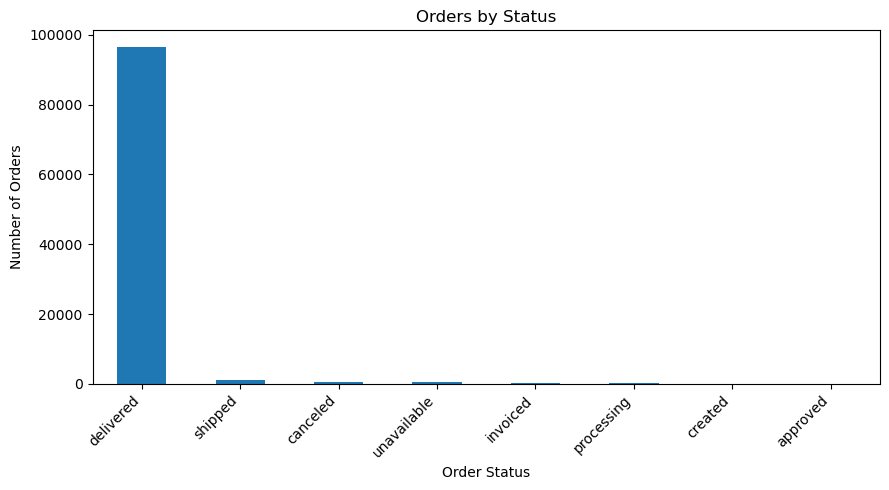

In [70]:
plt.figure(figsize=(9, 5))
order_status_counts.plot(kind="bar")
plt.title("Orders by Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "orders_by_status.png", dpi=150, bbox_inches="tight")
plt.show()

## 19. Monthly order trend

In [71]:
monthly_orders = (
    clean["orders"]
    .dropna(subset=["order_purchase_timestamp"])
    .assign(month=lambda x: x["order_purchase_timestamp"].dt.to_period("M").astype(str))
    .groupby("month")["order_id"]
    .nunique()
)

monthly_orders.tail()

month
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Name: order_id, dtype: int64

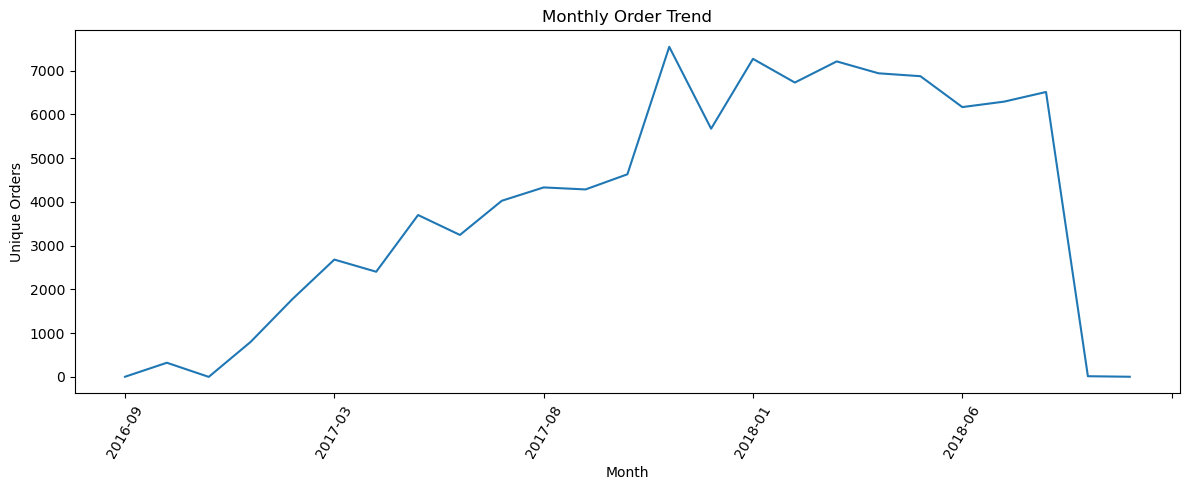

In [72]:
plt.figure(figsize=(12, 5))
monthly_orders.plot()
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Unique Orders")
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig(FIG_DIR / "monthly_order_trend.png", dpi=150, bbox_inches="tight")
plt.show()

## 20. Monthly delivered merchandise value

For this project, **merchandise value** is the sum of `order_items.price`.

Freight is reported separately.  
This is **not profit**, because the public dataset does not provide product cost/COGS.

In [73]:
monthly_gmv = (
    orders_enriched[
        orders_enriched["order_status"].eq("delivered")
        & orders_enriched["order_purchase_timestamp"].notna()
    ]
    .assign(month=lambda x: x["order_purchase_timestamp"].dt.to_period("M").astype(str))
    .groupby("month")["merchandise_value"]
    .sum()
)

monthly_gmv.tail()

month
2018-04   973,534.09
2018-05   977,544.69
2018-06   856,077.86
2018-07   867,953.46
2018-08   838,576.64
Name: merchandise_value, dtype: float64

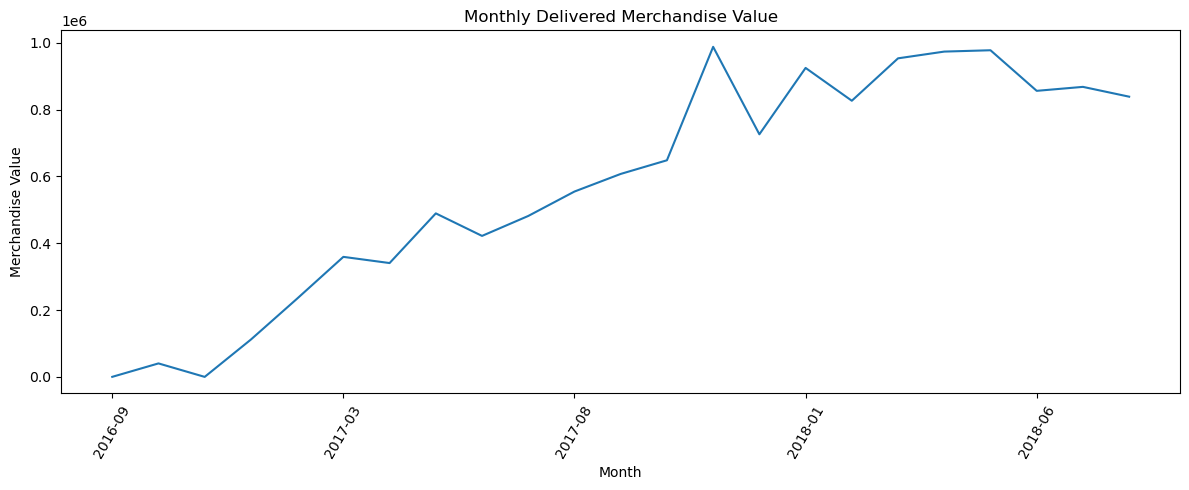

In [74]:
plt.figure(figsize=(12, 5))
monthly_gmv.plot()
plt.title("Monthly Delivered Merchandise Value")
plt.xlabel("Month")
plt.ylabel("Merchandise Value")
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig(FIG_DIR / "monthly_delivered_gmv.png", dpi=150, bbox_inches="tight")
plt.show()

## 21. Top product categories by delivered merchandise value

In [75]:
item_product = (
    clean["order_items"]
    .merge(
        clean["products"][["product_id", "product_category_english"]],
        on="product_id",
        how="left",
        validate="m:1",
    )
    .merge(
        clean["orders"][["order_id", "order_status"]],
        on="order_id",
        how="left",
        validate="m:1",
    )
)

top_categories = (
    item_product[item_product["order_status"].eq("delivered")]
    .groupby("product_category_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_categories

product_category_english
health_beauty           1,233,131.72
watches_gifts           1,166,176.98
bed_bath_table          1,023,434.76
sports_leisure            954,852.55
computers_accessories     888,724.61
furniture_decor           711,927.69
housewares                615,628.69
cool_stuff                610,204.10
auto                      578,966.65
toys                      471,286.48
garden_tools              470,495.28
baby                      400,421.84
perfumery                 390,144.65
telephony                 309,860.23
office_furniture          268,154.31
Name: price, dtype: float64

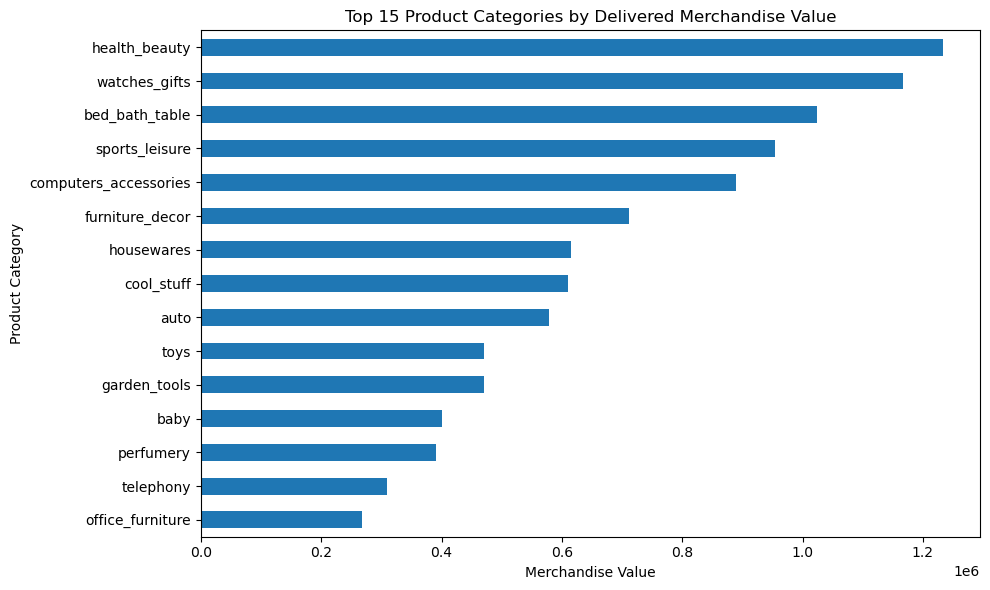

In [76]:
plt.figure(figsize=(10, 6))
top_categories.sort_values().plot(kind="barh")
plt.title("Top 15 Product Categories by Delivered Merchandise Value")
plt.xlabel("Merchandise Value")
plt.ylabel("Product Category")
plt.tight_layout()
plt.savefig(FIG_DIR / "top_categories_by_gmv.png", dpi=150, bbox_inches="tight")
plt.show()

## 22. Delivery-time distribution

In [77]:
delivery_days = orders_enriched.loc[
    orders_enriched["order_status"].eq("delivered")
    & orders_enriched["delivery_days"].notna(),
    "delivery_days",
]

delivery_days.describe()

count   96,470.00
mean        12.56
std          9.55
min          0.53
25%          6.77
50%         10.22
75%         15.72
max        209.63
Name: delivery_days, dtype: float64

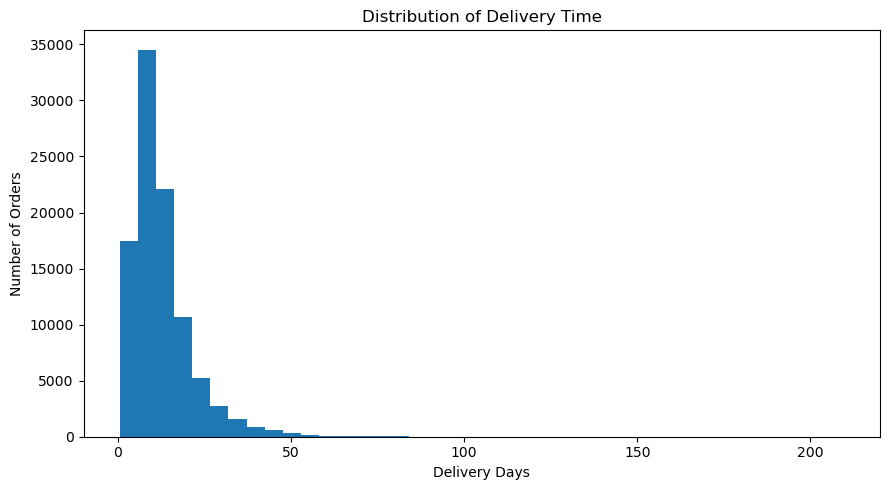

In [78]:
plt.figure(figsize=(9, 5))
plt.hist(delivery_days, bins=40)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig(FIG_DIR / "delivery_days_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 23. Late delivery vs review score

In [79]:
review_order = (
    clean["reviews"]
    .groupby("order_id", as_index=False)
    .agg(avg_review_score=("review_score", "mean"))
)

delivery_review = (
    orders_enriched[["order_id", "is_late_delivery"]]
    .merge(
        review_order,
        on="order_id",
        how="inner",
        validate="1:1",
    )
)

late_review_summary = (
    delivery_review
    .groupby("is_late_delivery", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        avg_review_score=("avg_review_score", "mean"),
    )
)

late_review_summary

,is_late_delivery,orders,avg_review_score
0,0,91011,4.21
1,1,7662,2.57


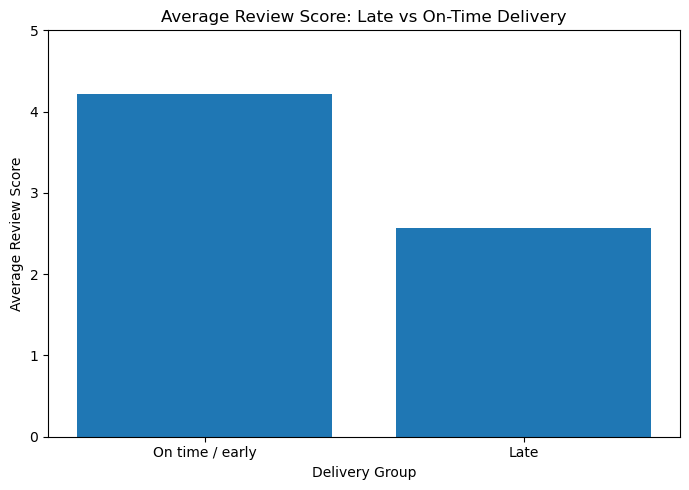

In [80]:
plot_data = late_review_summary.copy()
plot_data["delivery_group"] = plot_data["is_late_delivery"].map({
    0: "On time / early",
    1: "Late",
})

plt.figure(figsize=(7, 5))
plt.bar(plot_data["delivery_group"], plot_data["avg_review_score"])
plt.title("Average Review Score: Late vs On-Time Delivery")
plt.xlabel("Delivery Group")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig(FIG_DIR / "late_delivery_vs_review.png", dpi=150, bbox_inches="tight")
plt.show()

The chart shows an association only. It should not be presented as proof that late delivery *causes* lower review scores.

## 24. Customer repeat behavior

In [81]:
repeat_summary = (
    customer_order_counts["is_repeat_customer"]
    .value_counts()
    .rename(index={0: "One-time customer", 1: "Repeat customer"})
)

repeat_summary

is_repeat_customer
One-time customer    93099
Repeat customer       2997
Name: count, dtype: int64

In [82]:
repeat_rate = customer_order_counts["is_repeat_customer"].mean() * 100
print(f"Repeat-customer rate: {repeat_rate:.2f}%")

Repeat-customer rate: 3.12%


## 25. Payment method distribution

In [83]:
payment_type_summary = (
    clean["payments"]
    .groupby("payment_type", as_index=False)
    .agg(
        payment_rows=("order_id", "count"),
        payment_value=("payment_value", "sum"),
    )
    .sort_values("payment_value", ascending=False)
)

payment_type_summary

,payment_type,payment_rows,payment_value
1,credit_card,76795,"12,542,084.19"
0,boleto,19784,"2,869,361.27"
4,voucher,5775,"379,436.87"
2,debit_card,1529,"217,989.79"
3,not_defined,3,0.00


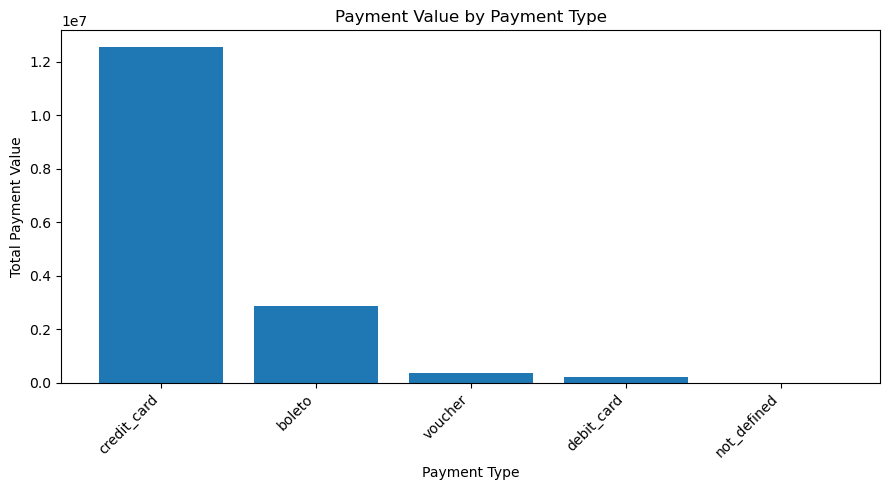

In [84]:
plt.figure(figsize=(9, 5))
plt.bar(payment_type_summary["payment_type"], payment_type_summary["payment_value"])
plt.title("Payment Value by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Total Payment Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "payment_value_by_type.png", dpi=150, bbox_inches="tight")
plt.show()

## 26. Product demand velocity — inventory-planning proxy

The public Olist dataset does **not** include warehouse stock-on-hand snapshots.

Therefore this project does not claim to measure actual inventory levels or stock-outs.

Instead, the notebook creates a **demand-velocity proxy** from delivered item history.

In [85]:
delivered_items = (
    clean["order_items"]
    .merge(
        clean["orders"][["order_id", "order_status", "order_purchase_timestamp"]],
        on="order_id",
        how="left",
        validate="m:1",
    )
)

delivered_items = delivered_items[
    delivered_items["order_status"].eq("delivered")
].copy()

product_demand = (
    delivered_items
    .groupby("product_id", as_index=False)
    .agg(
        delivered_item_lines=("order_item_id", "count"),
        delivered_orders=("order_id", "nunique"),
        first_sale_date=("order_purchase_timestamp", "min"),
        last_sale_date=("order_purchase_timestamp", "max"),
        delivered_merchandise_value=("price", "sum"),
    )
)

product_demand["active_months"] = (
    (
        product_demand["last_sale_date"].dt.year * 12
        + product_demand["last_sale_date"].dt.month
    )
    - (
        product_demand["first_sale_date"].dt.year * 12
        + product_demand["first_sale_date"].dt.month
    )
    + 1
)

product_demand["item_lines_per_active_month"] = np.where(
    product_demand["active_months"] > 0,
    product_demand["delivered_item_lines"] / product_demand["active_months"],
    np.nan,
)

dataset_end_date = clean["orders"]["order_purchase_timestamp"].max()

product_demand["days_since_last_sale"] = (
    dataset_end_date - product_demand["last_sale_date"]
).dt.days

velocity_median = product_demand["item_lines_per_active_month"].median()

product_demand["demand_segment"] = np.select(
    [
        (product_demand["days_since_last_sale"] <= 60)
        & (product_demand["item_lines_per_active_month"] >= velocity_median),
        (product_demand["days_since_last_sale"] <= 60)
        & (product_demand["item_lines_per_active_month"] < velocity_median),
        product_demand["days_since_last_sale"] > 180,
    ],
    [
        "fast_moving_recent",
        "slow_moving_recent",
        "inactive_or_old",
    ],
    default="moderate",
)

product_demand.head()

,product_id,delivered_item_lines,delivered_orders,first_sale_date,last_sale_date,delivered_merchandise_value,active_months,item_lines_per_active_month,days_since_last_sale,demand_segment
0,00066f42aeeb9f3007548bb9d3f33c38,1,1,2018-05-20 18:45:21,2018-05-20 18:45:21,101.65,1,1.00,149,moderate
1,00088930e925c41fd95ebfe695fd2655,1,1,2017-12-12 19:20:28,2017-12-12 19:20:28,129.90,1,1.00,308,inactive_or_old
2,0009406fd7479715e4bef61dd91f2462,1,1,2017-12-21 16:21:47,2017-12-21 16:21:47,229.00,1,1.00,300,inactive_or_old
3,000b8f95fcb9e0096488278317764d19,2,2,2018-08-01 22:00:33,2018-08-10 13:24:35,117.80,1,2.00,68,moderate
4,000d9be29b5207b54e86aa1b1ac54872,1,1,2018-04-03 09:24:12,2018-04-03 09:24:12,199.00,1,1.00,197,inactive_or_old


## 27. Export cleaned and analytical datasets

These processed CSV files are prepared for:
- SQL Server import,
- Excel reconciliation,
- Power BI modeling.

The original raw files remain unchanged.

In [86]:
for name, df in clean.items():
    output_path = PROCESSED_DIR / f"{name}_clean.csv"
    df.to_csv(output_path, index=False)

orders_enriched.to_csv(
    PROCESSED_DIR / "orders_enriched.csv",
    index=False
)

customer_order_counts.to_csv(
    PROCESSED_DIR / "customer_order_counts.csv",
    index=False
)

product_demand.to_csv(
    PROCESSED_DIR / "product_demand_proxy.csv",
    index=False
)

print("Processed files exported to:", PROCESSED_DIR.resolve())

Processed files exported to: D:\Olist-Ecommerce-Analytics\data\processed


## 28. Final QA summary

In [87]:
final_qa = pd.DataFrame({
    "check": [
        "Raw datasets loaded",
        "Exact duplicate rows reviewed",
        "Missing values profiled",
        "Referential integrity checked",
        "Business rules checked",
        "Outliers flagged, not blindly deleted",
        "Processed CSV files exported",
    ],
    "status": [
        "PASS" if len(data) == len(FILES) else "CHECK",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
    ],
})

final_qa

,check,status
0,Raw datasets loaded,PASS
1,Exact duplicate rows reviewed,PASS
2,Missing values profiled,PASS
3,Referential integrity checked,PASS
4,Business rules checked,PASS
5,"Outliers flagged, not blindly deleted",PASS
6,Processed CSV files exported,PASS


In [88]:
final_qa.to_csv(QA_DIR / "final_qa_summary.csv", index=False)

# Interview Notes

### Why did you use Python before SQL Server?
Python was used for repeatable data profiling, validation, missing-value checks, duplicate analysis, outlier flagging, feature engineering, EDA and preparation of clean CSV files. SQL Server was then used for relational business analysis and KPI queries.

### Did you remove all missing values?
No. Missing values were interpreted in business context. For example, undelivered or cancelled orders can legitimately have missing delivery timestamps.

### Did you remove all outliers?
No. Outliers were flagged using the IQR method. A large transaction can be genuine, so it should not be removed automatically.

### Why did you aggregate order items and payments before joining them?
Both tables can contain multiple rows per order. Joining them directly can create a many-to-many fan-out and inflate money values. I aggregated each table to one row per `order_id` before reconciliation.

### Did you calculate profit?
No. The public source does not provide COGS, so merchandise value and freight are reported instead of claiming gross profit.

### Did you calculate real inventory or stock-outs?
No. The source does not contain warehouse stock snapshots. The project uses an explicitly labelled demand-velocity proxy for inventory-planning discussion.